In [1]:
import os
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import time
import tm
import tqdm
import copy
import sys
import datasetutils
plt.style.use('dark_background') # i prefer this color scheme but need to install. coment if not working

In [2]:
#import importlib
#importlib.reload(tm)


******* ModelSet *******

Model weights


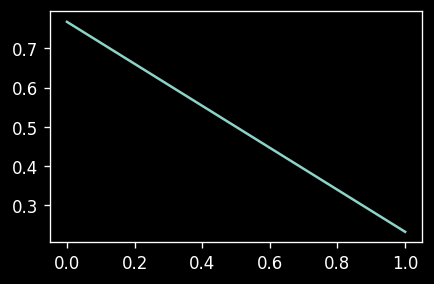

strat1 0.7679439711220937
strat2 0.23205602887790638


-> For key strat1


* Model *
** Linear Regression **
Weights:  [-3.90748217e-05  2.22548092e-01]
Variance:  9.792420754797549e-05


k:  37.54204604675084
Weight mean:  [0.]
external multiplier:  1
leverage scale:  12.514015348916946



-> For key strat2


* Model *
** Linear Regression **
Weights:  [4.30246623e-05 2.05099829e-01]
Variance:  0.0009077571537519141


k:  11.34439288432857
Weight mean:  [0.]
external multiplier:  1
leverage scale:  3.7814642947761903


*************************


In [3]:

n = 1000
x = np.random.normal(0, 0.01, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,0.01,n)
df1 = pd.DataFrame()
df1['x'] = x
df1['y'] = y
df1.index = pd.date_range('2000-01-01', freq = 'D', periods = n)

n = 1000
x = np.random.normal(0, 0.03, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,0.03,n)
df2 = pd.DataFrame()
df2['y'] = y
df2['x'] = x
df2.index = pd.date_range('2002-01-01', freq = 'D', periods = n)


dataset = tm.Dataset()
dataset.add('strat1', df1)
dataset.add('strat2', df2)

model_set = tm.ModelSet()

base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal()
model1 = tm.Model(base_model = base_model, allocation = alloc)   
model_set.add('strat1', model1)     


base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal()
model2 = tm.Model(base_model = base_model, allocation = alloc)   
model_set.add('strat2', model2)    


model_set.estimate(dataset) 
model_set.view()


In [4]:
# 3 - RUN CVBT
# this part is always the same and is easy
paths = tm.cvbt(
        dataset = dataset, 
        modelset = model_set,            
        n_paths = 3,
        k_folds = 5, 
        seq_path = False, 
        start_fold = 0, 
        burn_fraction = 0.1, 
        min_burn_points = 3,
        view_after_estimate = False
        )


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 12.01it/s]


In [5]:
paths

[{'strat1':                    y         x  msidx         s        sw       w_y
  2000-01-01  0.010993 -0.003325    0.0 -0.002196  0.777418 -0.199771
  2000-01-02 -0.016525 -0.009645    0.0  0.009795  0.777418 -0.592760
  2000-01-03 -0.009259 -0.009873    0.0  0.005620  0.777418 -0.606930
  2000-01-04  0.000112  0.001048    0.0  0.000008  0.777418  0.072124
  2000-01-05  0.013175 -0.004438    0.0 -0.003544  0.777418 -0.269004
  ...              ...       ...    ...       ...       ...       ...
  2002-09-22 -0.005244  0.012238    0.0 -0.003681  0.759785  0.701933
  2002-09-23  0.005851 -0.010175    0.0 -0.004034  0.759785 -0.689354
  2002-09-24 -0.014379  0.003920    0.0 -0.002668  0.759785  0.185542
  2002-09-25  0.002717 -0.004130    0.0 -0.000853  0.759785 -0.314109
  2002-09-26 -0.000480  0.011705    0.0 -0.000321  0.759785  0.668805
  
  [1000 rows x 6 columns],
  'strat2':                    y         x  msidx         s        sw       w_y
  2002-01-01  0.002778 -0.018469    0.0 

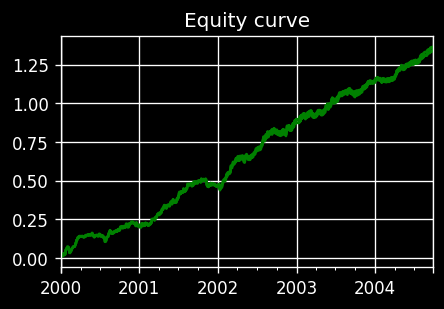

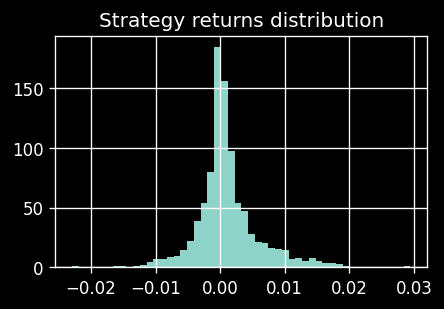

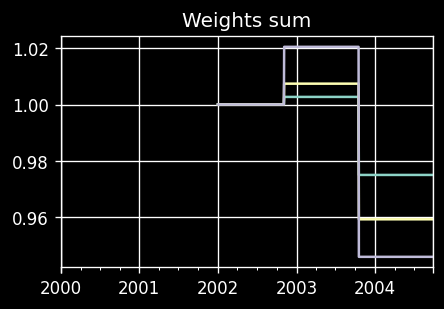

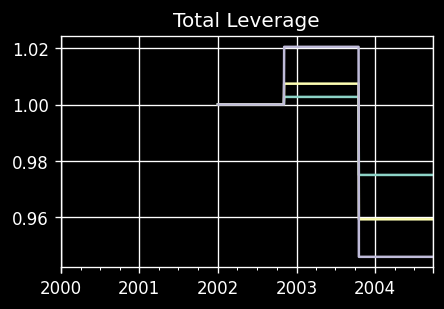

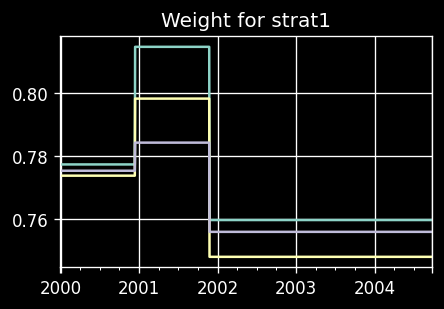

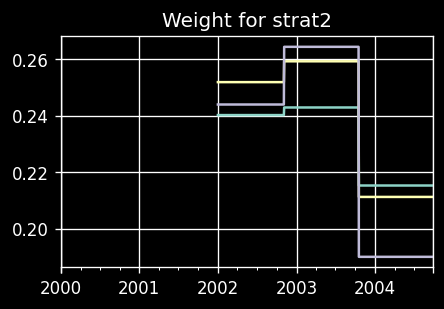

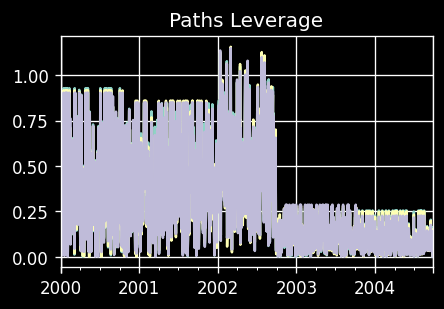

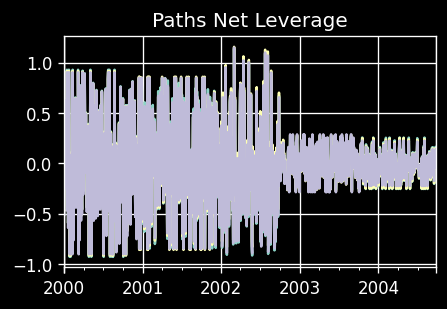

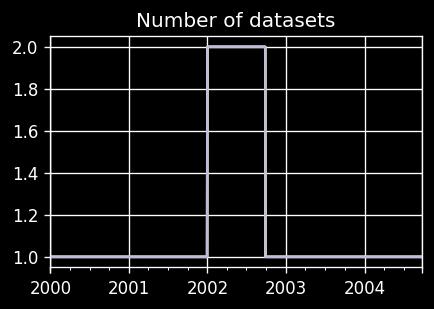

** ACCEPT STRATEGY from normal approximation of bootstrap Sharpe [alpha = 5e-05]**


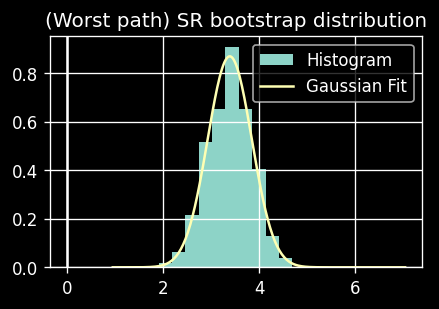


** PERFORMANCE SUMMARY **

Return:  0.2730384739989001
Standard deviation:  0.07928036046167068
Sharpe:  3.443961056797979



{'strategy':               path_1    path_2    path_3
 1999-12-31  0.007615  0.007692  0.008383
 2000-01-03  0.004369  0.004411  0.004802
 2000-01-04  0.000006  0.000006  0.000003
 2000-01-05 -0.002755 -0.002829 -0.003259
 2000-01-06 -0.000011 -0.000008  0.000003
 ...              ...       ...       ...
 2004-09-20  0.001468  0.001285  0.001298
 2004-09-21  0.001708  0.001810  0.001429
 2004-09-22  0.000560  0.000575  0.000473
 2004-09-23  0.004740  0.004385  0.004130
 2004-09-24 -0.000039 -0.000086 -0.000021
 
 [1236 rows x 3 columns],
 'leverage':               path_1    path_2    path_3
 1999-12-31  0.460822  0.465464  0.507294
 2000-01-03  0.471838  0.476437  0.518669
 2000-01-04  0.056070  0.049439  0.026477
 2000-01-05  0.209128  0.214739  0.247381
 2000-01-06  0.023059  0.016556  0.007612
 ...              ...       ...       ...
 2004-09-20  0.054299  0.047513  0.048015
 2004-09-21  0.037114  0.039320  0.031053
 2004-09-22  0.053170  0.054572  0.044941
 2004-09-23  0.163411  0

In [6]:
paths.portfolio_post_process(pct_fee = 0)
